Code to check if the feature embeddings and the labels in the list all match 

In [4]:
import os
import numpy as np

# Paths
train_list_path = "list/data_Train.list"
test_list_path = "list/data_Test.list"
feature_dir = "feature_embeddings/"  # folder containing your .npy embeddings

def load_vid_list(list_path):
    with open(list_path, "r") as f:
        return [line.strip().split()[0] for line in f]

def check_embeddings(vid_list, feature_dir):
    missing = []
    for vid_path in vid_list:
        filename = os.path.basename(vid_path)  # get filename from path
        feature_path = os.path.join(feature_dir, filename)
        if not os.path.exists(feature_path):
            missing.append(filename)
    return missing

# Load train/test lists
train_videos = load_vid_list(train_list_path)
test_videos = load_vid_list(test_list_path)

# Check embeddings
missing_train = check_embeddings(train_videos, feature_dir)
missing_test = check_embeddings(test_videos, feature_dir)

print(f"Missing train embeddings ({len(missing_train)}): {missing_train}")
print(f"Missing test embeddings ({len(missing_test)}): {missing_test}")


Missing train embeddings (0): []
Missing test embeddings (0): []


### Inference


VIDEO-LEVEL METRICS:
ROC-AUC = 0.6691
Average Precision (AP) = 0.2638
All results saved in folder: plots/


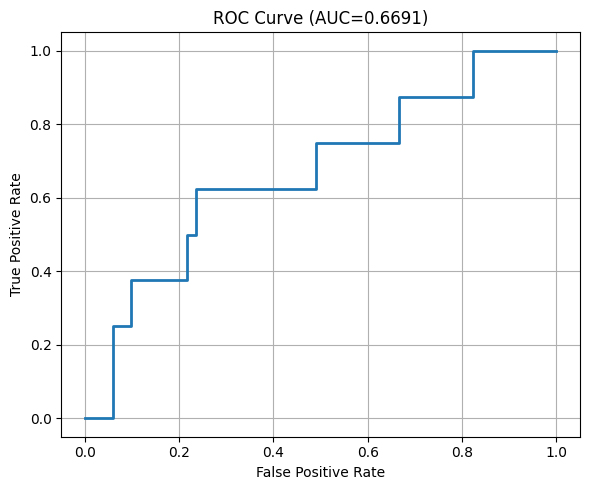

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.metrics import average_precision_score

from model import WSAD
from dataset_loader import FeatureDataset

# ======================================================================
# Inference Function
# ======================================================================
def run_inference(model, test_loader):
    model.eval()
    model.flag = "Test"

    video_scores = []
    video_labels = []
    snippet_scores_dict = {}

    with torch.no_grad():
        for data, label, name in test_loader:
            # data: [1, num_segments, feature_dim]
            label = int(label.item())
            name = name[0] if isinstance(name, (list, tuple)) else str(name)
            data = data.cuda()

            out = model(data)
            snippet_scores = out["frame"].squeeze().cpu().numpy()

            snippet_scores_dict[name] = snippet_scores
            video_scores.append(snippet_scores.max())
            video_labels.append(label)

    return video_scores, video_labels, snippet_scores_dict

# ======================================================================
# Metrics + Plots
# ======================================================================
def evaluate_and_plot(video_scores, video_labels):
    os.makedirs("plots", exist_ok=True)

    ap = average_precision_score(video_labels, video_scores)
    fpr, tpr, _ = roc_curve(video_labels, video_scores)
    roc_auc_val = auc(fpr, tpr)

    precision, recall, _ = precision_recall_curve(video_labels, video_scores)
    pr_auc_val = auc(recall, precision)

    print(f"\nVIDEO-LEVEL METRICS:")
    print(f"ROC-AUC = {roc_auc_val:.4f}")
    # print(f"PR-AUC  = {pr_auc_val:.4f}\n")
    print(f"Average Precision (AP) = {ap:.4f}")

    # ROC Curve
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, linewidth=2)
    plt.title(f"ROC Curve (AUC={roc_auc_val:.4f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True)
    plt.tight_layout()
    # plt.savefig("plots/roc_curve.png")
    # plt.close()

    

    return roc_auc_val, pr_auc_val

# ======================================================================
# MAIN
# ======================================================================
if __name__ == "__main__":

    # Load model
    model = WSAD(input_size=1024, flag="Test", a_nums=60, n_nums=60).cuda()
    model.load_state_dict(
        torch.load("models/moerdijk_trans_3000.pkl", map_location="cuda")
    )

    # Load test dataset
    test_dataset = FeatureDataset(
        root_dir=".",
        modal="RGB",
        mode="Test",
        num_segments=200,
        len_feature=1024,
    )
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

    # Inference
    video_scores, video_labels, snippet_scores_dict = run_inference(model, test_loader)

    # Evaluation
    roc_auc, pr_auc = evaluate_and_plot(video_scores, video_labels)

    # Optional: create a table of video scores + labels
    import pandas as pd
    df = pd.DataFrame({
        "Video Name": list(snippet_scores_dict.keys()),
        "Video Score": video_scores,
        "Video Label": video_labels
    })

    print("All results saved in folder: plots/")


In [6]:
df

,Video Name,Video Score,Video Label
0,video_eo_96_500_ab_i3d.npy,9.999957e-01,1
1,video_eo_96_2485_ab_i3d.npy,1.595202e-06,1
2,video_eo_96_4100_ab_i3d.npy,9.994525e-01,1
3,video_eo_96_5620_ab_i3d.npy,8.797147e-07,1
4,video_eo_96_11025_ab_i3d.npy,3.202708e-07,1
5,video_eo_96_15365_ab_i3d.npy,2.593780e-07,1
6,video_eo_96_20945_ab_i3d.npy,8.794624e-08,1
7,video_eo_96_21913_ab_i3d.npy,3.942919e-07,1
8,video_eo_96_0_norm_i3d.npy,1.548721e-06,0
9,video_eo_96_1816_norm_i3d.npy,1.167456e-01,0
